In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- 1. Wireless Environment Parameters ---
B_HZ = 1e6              # 1 MHz
N0_DBM_HZ = -174        # Noise density
P_TX_CLIENT_DBM = 24    # Uplink Power
P_TX_SERVER_DBM = 46    # Downlink Power (Server)
Q_BITS = 16             # 16-bit quantization
RADIUS_KM = 0.5         # 500m
DEVICE_GFLOPS = 2.0     # Average edge device speed (2 Billion operations/sec)

In [3]:
# --- 2. Model Architectures ---

class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

In [5]:
# --- 3. Wireless Channel ---

def get_round_delays(model, task):
    # --- 3.1. Wireless Environment Setup ---
    # Total Bandwidth B = 1MHz
    B_total = B_HZ 
    K = 30 # Number of devices
    
    # OFDMA Uplink: Each device gets a sub-channel Bk
    Bk = B_total / K 
    
    # Noise calculation (N0 * Bandwidth)
    # For Uplink: Noise power in sub-channel Bk
    noise_w_up = 10**(((N0_DBM_HZ + 10 * np.log10(Bk)) - 30) / 10)
    # For Downlink: Noise power in total bandwidth B
    noise_w_down = 10**(((N0_DBM_HZ + 10 * np.log10(B_total)) - 30) / 10)

    # Path Loss & Distances
    r_km = RADIUS_KM * np.sqrt(np.random.rand(K)) 
    path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
    
    # Payload Size (N * q)
    num_params = sum(p.numel() for p in model.parameters())
    payload_bits = num_params * Q_BITS

    # --- 3.2. Downlink Calculation (Equation 5) ---
    # Downlink SNR (gamma) is determined by the device with the worst channel gain
    p_rx_dbm_down = P_TX_SERVER_DBM - path_loss_db
    p_rx_w_down = 10**((p_rx_dbm_down - 30) / 10)
    
    gamma_down = np.min(p_rx_w_down / noise_w_down) # Minimum SNR among devices
    r_downlink = B_total * np.log2(1 + gamma_down)  # Achievable rate r
    d_down = payload_bits / r_downlink

    # --- 3.3. Uplink Calculation (Equation 4) ---
    # Achievable rate r_k for each device k using sub-channel Bk
    p_rx_dbm_up = P_TX_CLIENT_DBM - path_loss_db
    p_rx_w_up = 10**((p_rx_dbm_up - 30) / 10)
    
    gamma_up = p_rx_w_up / noise_w_up         # SNR gamma_k for each device
    rk_uplink = Bk * np.log2(1 + gamma_up)    # Achievable rate r_k
    
    # Total Uplink delay is the time until the last device k finishes
    d_up = np.max(payload_bits / rk_uplink)

    # --- 3.4. Computation Delay ---
    flops_per_img = 6000 if task == 'SVM' else 15_000_000
    num_samples = 330 if task == 'SVM' else 2000
    t_comp = (num_samples * flops_per_img) / (DEVICE_GFLOPS * 1e9)

    return d_down, t_comp, d_up

In [6]:
# --- 4. Data Preparation ---

def get_datasets(task='CNN'):
    if task == 'SVM':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
        # Filter classes 0 (airplane) and 1 (automobile)
        train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
        test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
        
        # 15 devices get only airplanes, 15 get only automobiles (330 samples each)
        airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*330]
        autos = [i for i in train_idx if train_set.targets[i] == 1][:15*330]
        
        device_data = [Subset(train_set, airplanes[i*330:(i+1)*330]) for i in range(15)] + \
                      [Subset(train_set, autos[i*330:(i+1)*330]) for i in range(15)]
        
        return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001

    else: # CNN Task
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        
        # Pathological Non-IID: Sort by label, 60 shards, 2 per client
        indices = np.argsort(train_set.targets.numpy())
        shards = [indices[i*1000 : (i+1)*1000] for i in range(60)]
        device_data = [Subset(train_set, np.concatenate((shards[i*2], shards[i*2+1]))) for i in range(30)]
        
        return device_data, test_set, CNNModel(), 0.005

In [7]:
def get_optimal_probabilities(n_k_list, grad_norms, T_u_list, rho):
    """
    Implements Theorem 1 with safeguards for baseline cases (rho=0 or 1).
    """
    n_total = sum(n_k_list)
    grad_norms = np.array(grad_norms) + 1e-12 
    T_u_list = np.array(T_u_list)

    # Shortcut for Channel-aware (rho=0) 
    if rho == 0:
        # Probability is inversely proportional to sqrt of latency
        p = 1.0 / np.sqrt(T_u_list + 1e-12)
        return p / np.sum(p)

    # Shortcut for Importance-aware (rho=1) [cite: 504]
    if rho == 1:
        # Probability is proportional to (n_k/n) * ||g_k||
        p = (np.array(n_k_list) / n_total) * grad_norms
        return p / np.sum(p)

    # Bisection search for Proposed Policy (0 < rho < 1) [cite: 322, 325]
    def compute_p_star(lam):
        denom = (1 - rho) * T_u_list + lam
        # Theorem 1: p_k is proportional to (n_k/n)*||g_k|| * sqrt(rho/denom)
        p = (np.array(n_k_list) / n_total) * grad_norms * np.sqrt(rho / np.maximum(denom, 1e-15))
        return p

    # Find search bounds for lambda
    # denom must be > 0, so lam > -(1-rho)*T_u_min
    low = -np.min((1 - rho) * T_u_list) + 1e-12
    high = 1e6
    
    for _ in range(100):
        mid = (low + high) / 2
        p_temp = compute_p_star(mid)
        if np.sum(p_temp) > 1:
            low = mid
        else:
            high = mid
            
    final_p = compute_p_star(high)
    return final_p / np.sum(final_p)

In [8]:
def get_multi_device_selection(n_k_list, grad_norms, T_u_list_full_B, rho, M):
    """
    Implements Algorithm 1: Importance- and Channel-Aware Scheduling 
    without replacement[cite: 377, 399].
    """
    # 1. Compute initial optimal scheduling distribution P* (Equation 25) [cite: 400]
    p_star = get_optimal_probabilities(n_k_list, grad_norms, T_u_list_full_B, rho)
    
    selected_indices = []
    current_p = p_star.copy()
    
    for m in range(M):
        # Normalize current distribution to ensure sum = 1 [cite: 382, 400]
        current_p = current_p / np.sum(current_p)
        
        # 2. Randomly select device based on conditional distribution [cite: 400]
        idx = np.random.choice(range(len(p_star)), p=current_p)
        selected_indices.append(idx)
        
        # 3. Update distribution for next selection (sampling without replacement) [cite: 389]
        # Store the conditional probability q_k used for this selection [cite: 382]
        # In the next step, the probability for this device becomes 0
        current_p[idx] = 0
        
    return selected_indices, p_star

In [17]:
# --- 5. Main Training Logic ---

def run_multi_device_fl(task='SVM', rounds=50, rho=5e-6, M=10):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    n_k_list = [len(d) for d in device_data]
    n_total = sum(n_k_list)
    lmbda = 0.01 
    r_km = RADIUS_KM * np.sqrt(np.random.rand(30))
    
    history = {'acc': [], 'time': []}
    cumulative_time = 0

    print(f"\n--- Multi-Device Simulation: {task} | M={M} | {rounds} Rounds ---")

    for r in range(rounds):
        # Step 1: Wireless Environment 
        path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
        
        noise_up_w = 10**(((N0_DBM_HZ + 10 * np.log10(B_HZ)) - 30) / 10)
        p_rx_up_w = 10**(((P_TX_CLIENT_DBM - path_loss_db) - 30) / 10)
        gamma_up = p_rx_up_w / noise_up_w
        
        # Downlink broadcast [cite: 259]
        p_rx_down_w = 10**(((P_TX_SERVER_DBM - path_loss_db) - 30) / 10)
        gamma_down_min = np.min(p_rx_down_w / noise_up_w) 
        
        num_params = sum(p.numel() for p in global_model.parameters())
        payload_bits = num_params * Q_BITS
        
        # T_u_list based on full bandwidth (required for Step 2 probability calculation) [cite: 418]
        T_u_full_B = payload_bits / (B_HZ * np.log2(1 + gamma_up))

        # Steps 2 & 3: Importance Evaluation (All devices calculate importance indicators) [cite: 277]
        grad_norms = []
        client_gradients = []
        for i in range(30):
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            loader = DataLoader(device_data[i], batch_size=len(device_data[i]))
            data, target = next(iter(loader))
            local_model.zero_grad()
            output = local_model(data).squeeze()
            if task == 'SVM':
                target_svm = (target.float() * 2) - 1 
                loss = 0.5 * torch.mean(torch.clamp(1 - target_svm * output, min=0)) + (lmbda / 2.0) * sum(p.pow(2).sum() for p in local_model.parameters())
            else:
                target_oh = torch.nn.functional.one_hot(target, num_classes=10).float()
                loss = 0.5 * torch.nn.functional.mse_loss(output, target_oh, reduction='mean')
            loss.backward()
            grads = [p.grad.detach().clone() for p in local_model.parameters()]
            grad_norms.append(torch.norm(torch.cat([g.view(-1) for g in grads])).item())
            client_gradients.append(grads)

        # Step 4: Device Selection Sequence [cite: 377, 399]
        selected_indices, p_star = get_multi_device_selection(n_k_list, grad_norms, T_u_full_B, rho, M)

        # Step 5: Latency with Bandwidth Allocation (Theorem 3) [cite: 436]
        # Uplink data rates with unit bandwidth R_k [cite: 428]
        R_k = np.log2(1 + gamma_up[selected_indices])
        
        # Total Upload Latency for M selected devices (Equalized) [cite: 429, 437]
        t_upload_equalized = (payload_bits / B_HZ) * np.sum(1.0 / R_k)
        
        t_broadcast = payload_bits / (B_HZ * np.log2(1 + gamma_down_min)) 
        t_comp_max = (max(n_k_list) * (6000 if task=='SVM' else 15e6)) / (DEVICE_GFLOPS * 1e9)
        
        cumulative_time += (t_broadcast + t_comp_max + t_upload_equalized)

        # Step 6: Global Model Update (Equation 29) [cite: 380]
        with torch.no_grad():
            global_grad_sum = [torch.zeros_like(p) for p in global_model.parameters()]
            
            # Sampling without replacement aggregation [cite: 382, 389]
            # q_k is the probability of selecting device k at step m given previous selections
            for m, idx in enumerate(selected_indices):
                # Conditional probability q_Y_m [cite: 382]
                sum_prev_p = sum(p_star[selected_indices[j]] for j in range(m))
                q_Y_m = p_star[idx] / (1.0 - sum_prev_p)
                
                # Scale local gradient [cite: 380, 393]
                scale = n_k_list[idx] / (n_total * q_Y_m)
                for g_sum, g_local in zip(global_grad_sum, client_gradients[idx]):
                    g_sum += (1.0 / M) * scale * g_local
            
            # Update global weights
            for p_global, g_agg in zip(global_model.parameters(), global_grad_sum):
                p_global -= lr * g_agg

        # Evaluation (same as original)
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                pred = torch.sign(output.squeeze()) if task == 'SVM' else output.argmax(1)
                labels = (target.float()*2-1) if task == 'SVM' else target
                correct += (pred == labels).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        
        print(f"Round {r+1:02d} | Acc: {acc:.2f}% | Sim Time: {cumulative_time:.2f}s")

    return history
    # # --- Plotting ---
    # plt.figure(figsize=(10, 5))
    # plt.plot(history['time'], history['acc'], 'b-o', markersize=4)
    # plt.title(f'Accuracy vs. Training Time ({task})')
    # plt.xlabel('Training Time (Seconds)')
    # plt.ylabel('Test Accuracy (%)')
    # plt.grid(True, alpha=0.3)
    # plt.show()

In [18]:
def run_multi_comparison(task='SVM', rounds=50):
    """
    Executes all multi-device scheduling policies for a specific task and plots the results.
    """
    # Define task-specific parameters based on Section VI.C 
    if task == 'SVM':
        M_devices = 10
        rhos = {0: 'Channel-aware', 
                1: 'Importance-aware', 
                5e-6: 'Proposed (5e-6)'}
        time_scale = 1 # Seconds
        x_label = "Training Time (seconds)"
    else: # CNN
        M_devices = 3
        rhos = {0: 'Channel-aware', 
                1: 'Importance-aware', 
                1e-3: 'Proposed (1e-3)'}
        time_scale = 60 # Minutes
        x_label = "Training Time (minutes)"
    
    results = {}
    
    print(f"--- Starting {task} Multi-Device Comparison (M={M_devices}) ---")
    for rho, label in rhos.items():
        print(f"Running {label} (rho={rho})...")
        # Ensure fresh model for each policy run
        results[label] = run_multi_device_fl(task=task, rounds=rounds, rho=rho, M=M_devices)

    # --- Plotting Results (Replicating Figure 4) ---
    plt.figure(figsize=(10, 6))
    for label, hist in results.items():
        # Convert time to appropriate scale (seconds or minutes) [cite: 571, 575]
        plt.plot(np.array(hist['time']) / time_scale, hist['acc'], label=label)
    
    plt.title(f"Multi-Device Performance Comparison: {task} Model (M={M_devices})")
    plt.xlabel(x_label)
    plt.ylabel("Test Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# To execute the multi-device simulation:
# run_multi_comparison(task='SVM', rounds=30)
# run_multi_comparison(task='CNN', rounds=50)

In [20]:
run_multi_device_fl(task='CNN', rounds=5, rho=0, M=3)


--- Multi-Device Simulation: CNN | M=3 | 5 Rounds ---
Round 01 | Acc: 11.98% | Sim Time: 18.08s
Round 02 | Acc: 12.31% | Sim Time: 36.92s
Round 03 | Acc: 12.12% | Sim Time: 55.42s
Round 04 | Acc: 12.08% | Sim Time: 73.88s
Round 05 | Acc: 12.26% | Sim Time: 92.78s


{'acc': [11.98, 12.31, 12.12, 12.08, 12.26],
 'time': [np.float64(18.080883356783232),
  np.float64(36.91643061662599),
  np.float64(55.41823527533188),
  np.float64(73.87679801058972),
  np.float64(92.77617379269105)]}

--- Starting CNN Multi-Device Comparison (M=3) ---
Running Channel-aware (rho=0)...

--- Multi-Device Simulation: CNN | M=3 | 1120 Rounds ---
Round 01 | Acc: 10.51% | Sim Time: 19.03s
Round 02 | Acc: 10.84% | Sim Time: 37.97s
Round 03 | Acc: 11.13% | Sim Time: 56.91s
Round 04 | Acc: 11.42% | Sim Time: 74.77s
Round 05 | Acc: 10.81% | Sim Time: 93.39s
Round 06 | Acc: 10.75% | Sim Time: 111.95s
Round 07 | Acc: 10.81% | Sim Time: 130.07s
Round 08 | Acc: 11.46% | Sim Time: 148.42s
Round 09 | Acc: 11.16% | Sim Time: 167.13s
Round 10 | Acc: 11.03% | Sim Time: 185.80s
Round 11 | Acc: 10.70% | Sim Time: 204.42s
Round 12 | Acc: 11.22% | Sim Time: 222.88s
Round 13 | Acc: 11.10% | Sim Time: 241.62s
Round 14 | Acc: 10.85% | Sim Time: 260.08s
Round 15 | Acc: 10.01% | Sim Time: 277.95s
Round 16 | Acc: 9.34% | Sim Time: 296.36s
Round 17 | Acc: 9.62% | Sim Time: 315.32s
Round 18 | Acc: 10.11% | Sim Time: 333.85s
Round 19 | Acc: 9.20% | Sim Time: 352.65s
Round 20 | Acc: 9.51% | Sim Time: 371.54s
Round 2

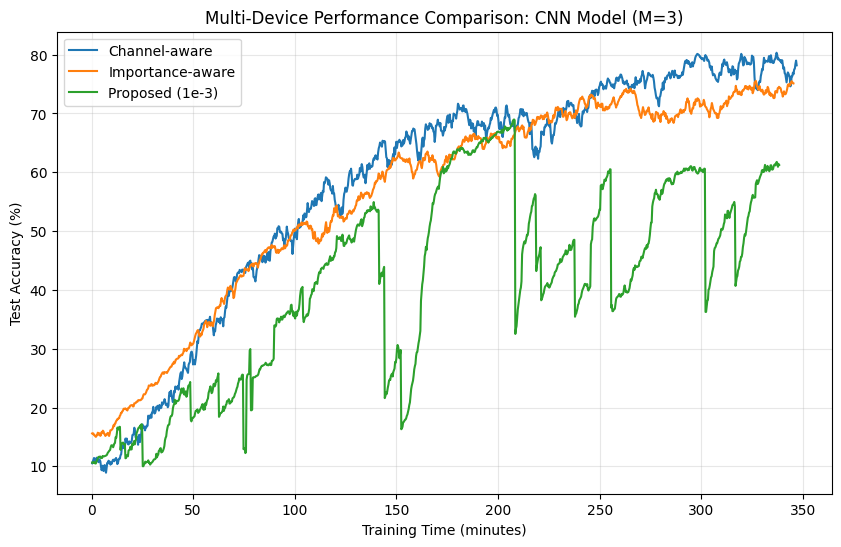

In [21]:
run_multi_comparison(task='CNN', rounds=1120)